# Exp12 Problem vs KC Matrices

This notebook shows the KC-gap matrix for each rater side by side: Human A, Human B, and LLM V3.

Each heatmap uses problems as rows and knowledge components as columns, so you can compare which rater tagged which KC on each problem.

Students found: ['10155', '14475', '14476']


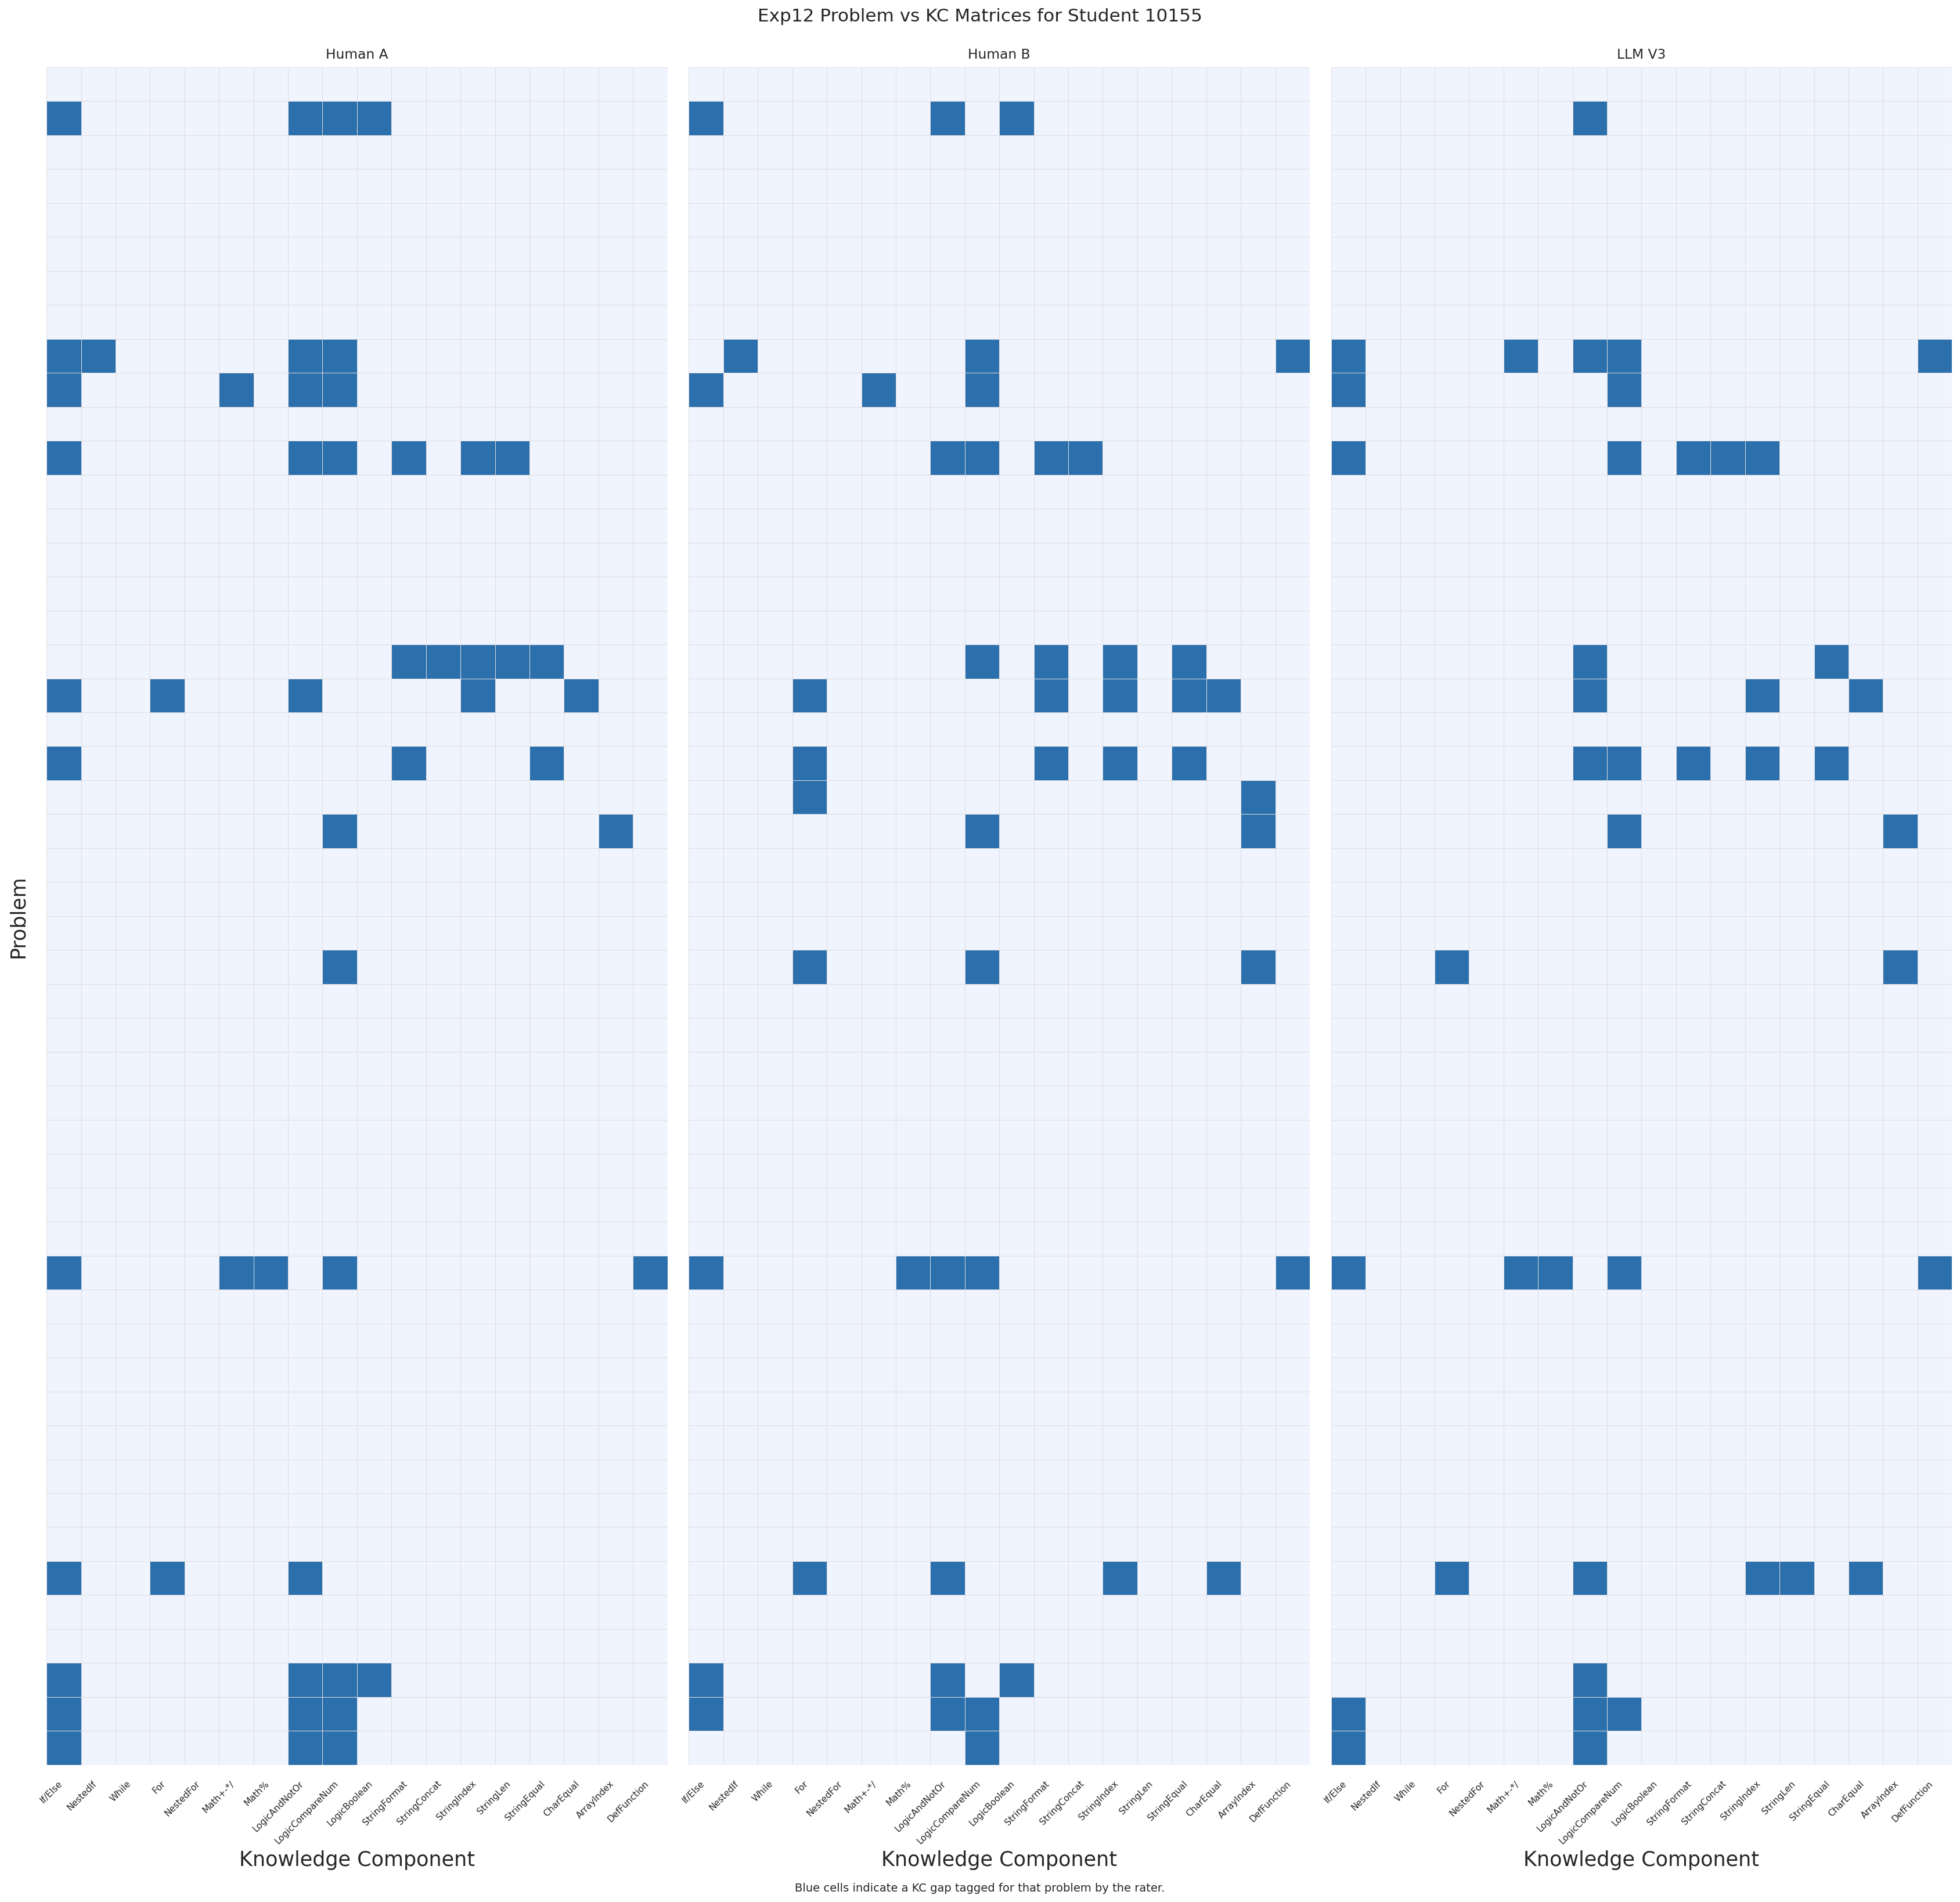

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp12_visualizations/exp12_problem_vs_kc_matrices_student_10155.png


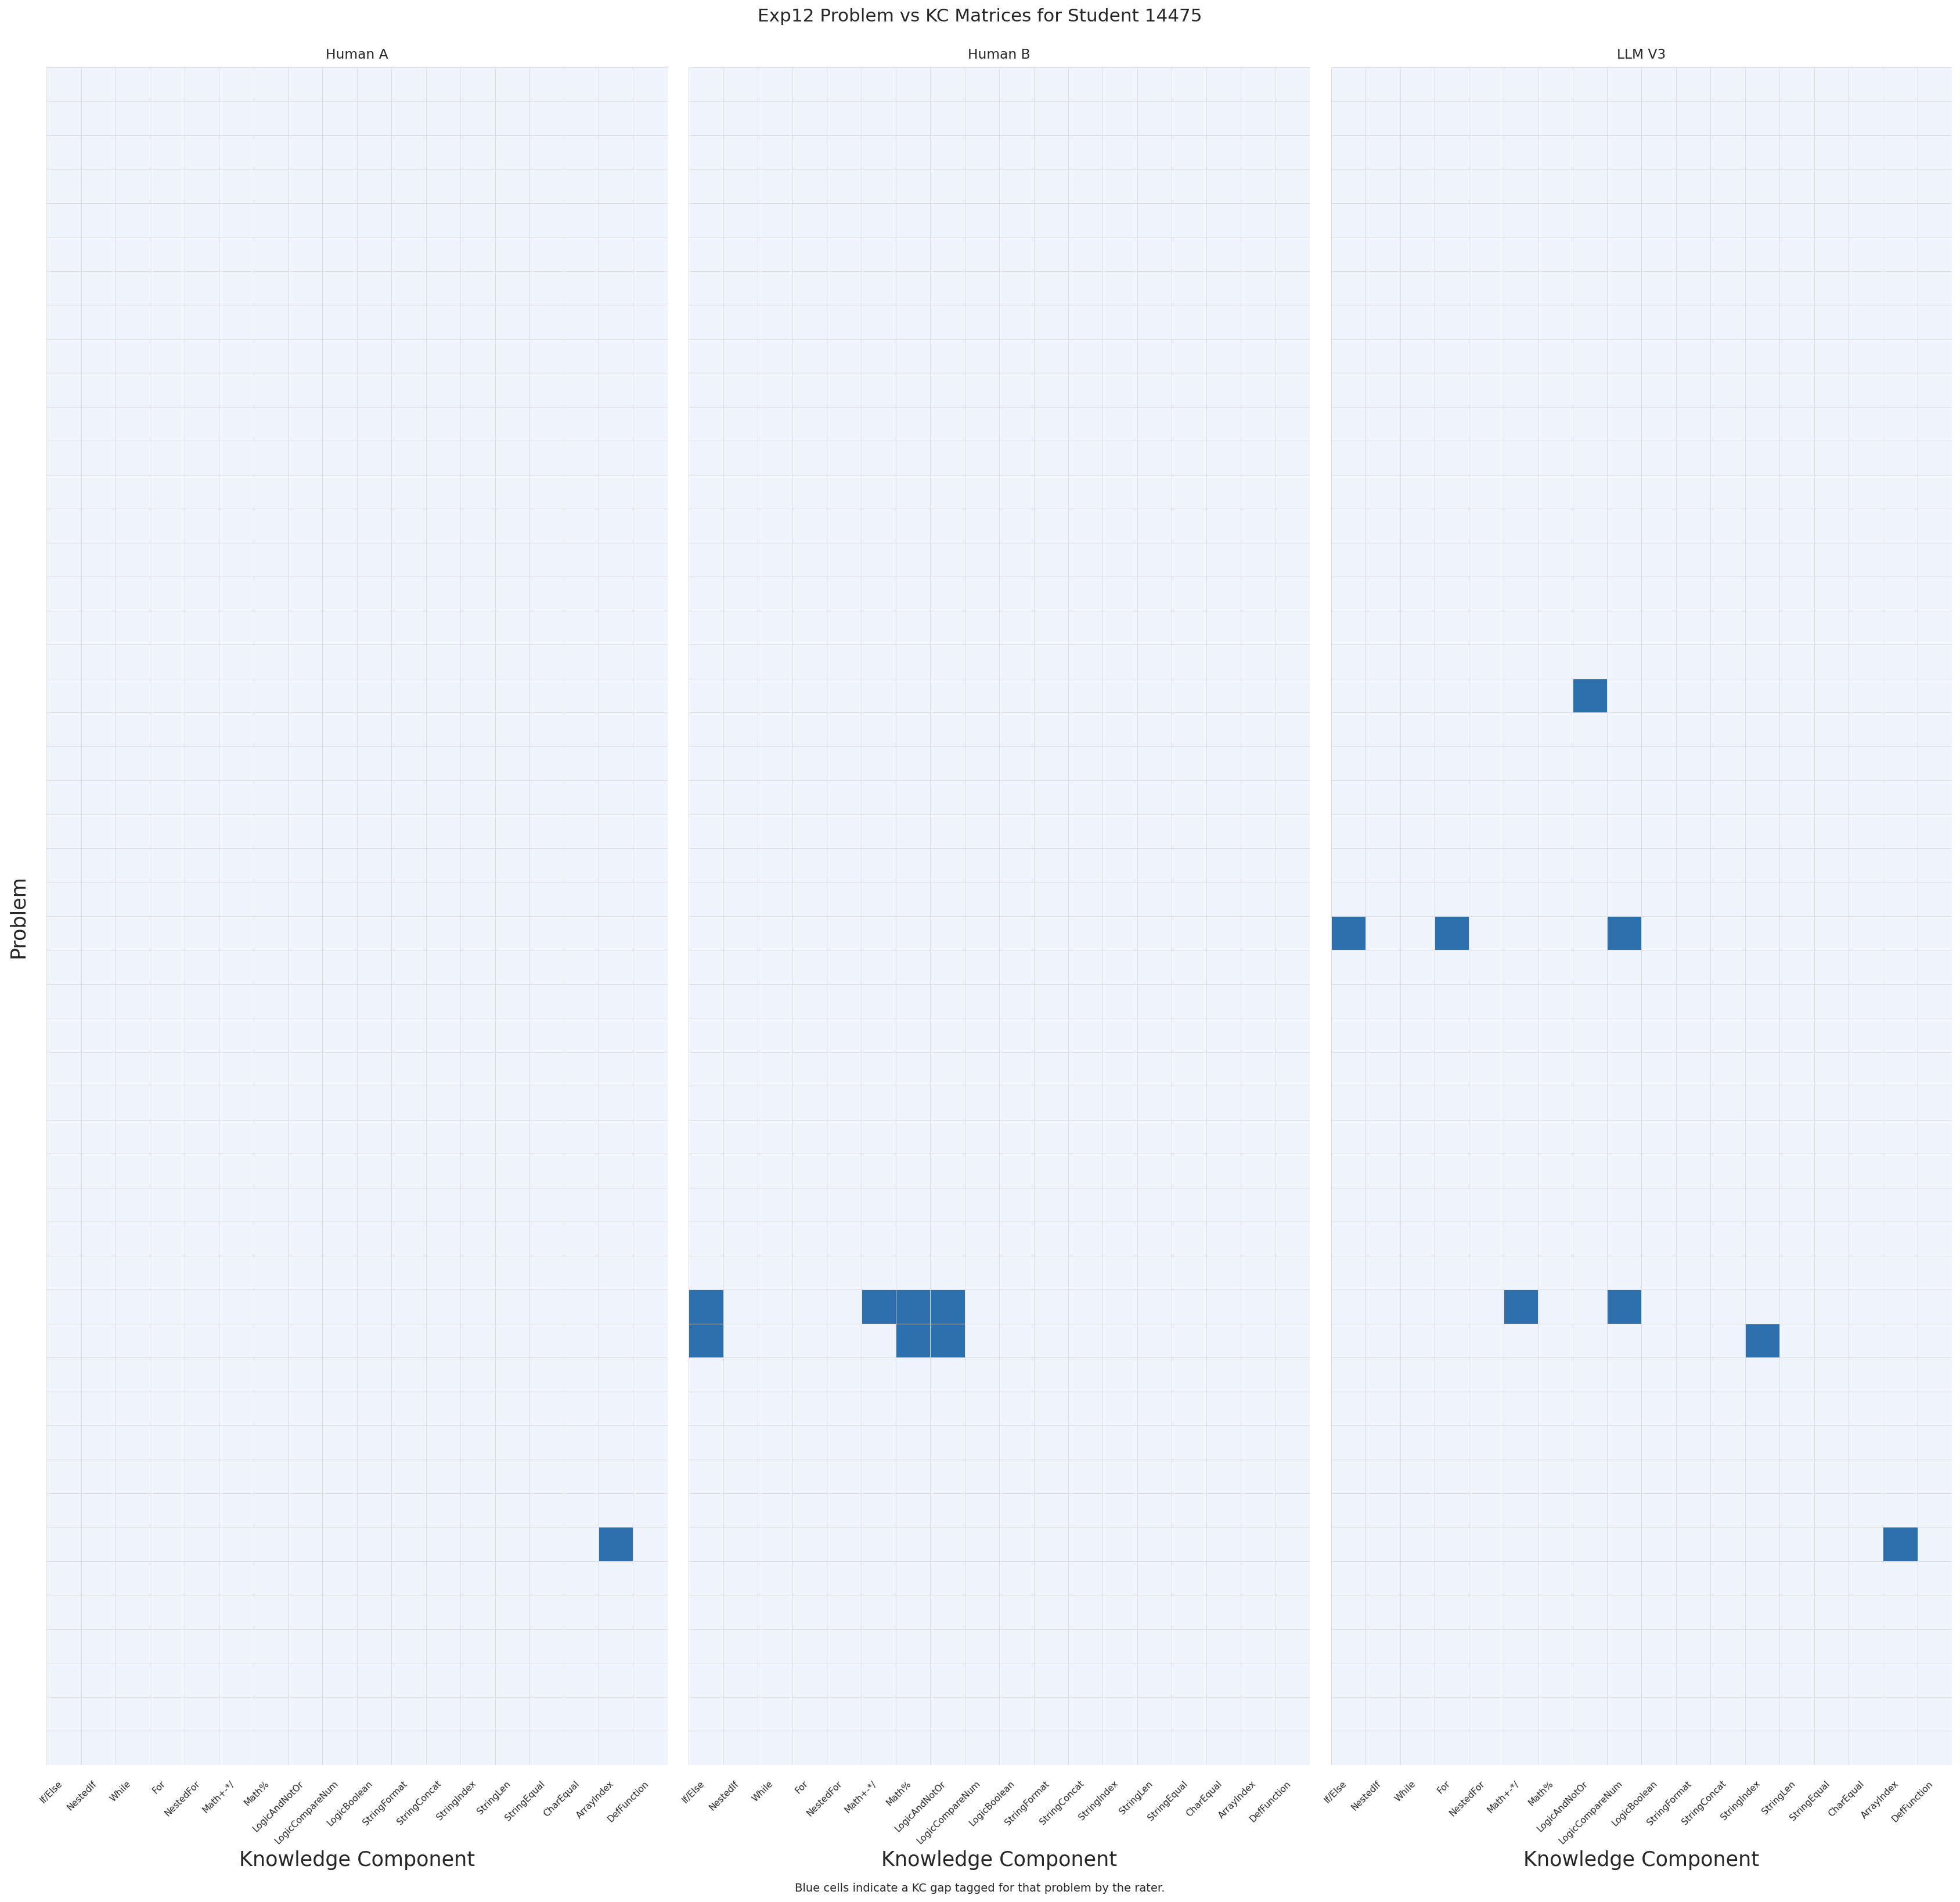

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp12_visualizations/exp12_problem_vs_kc_matrices_student_14475.png


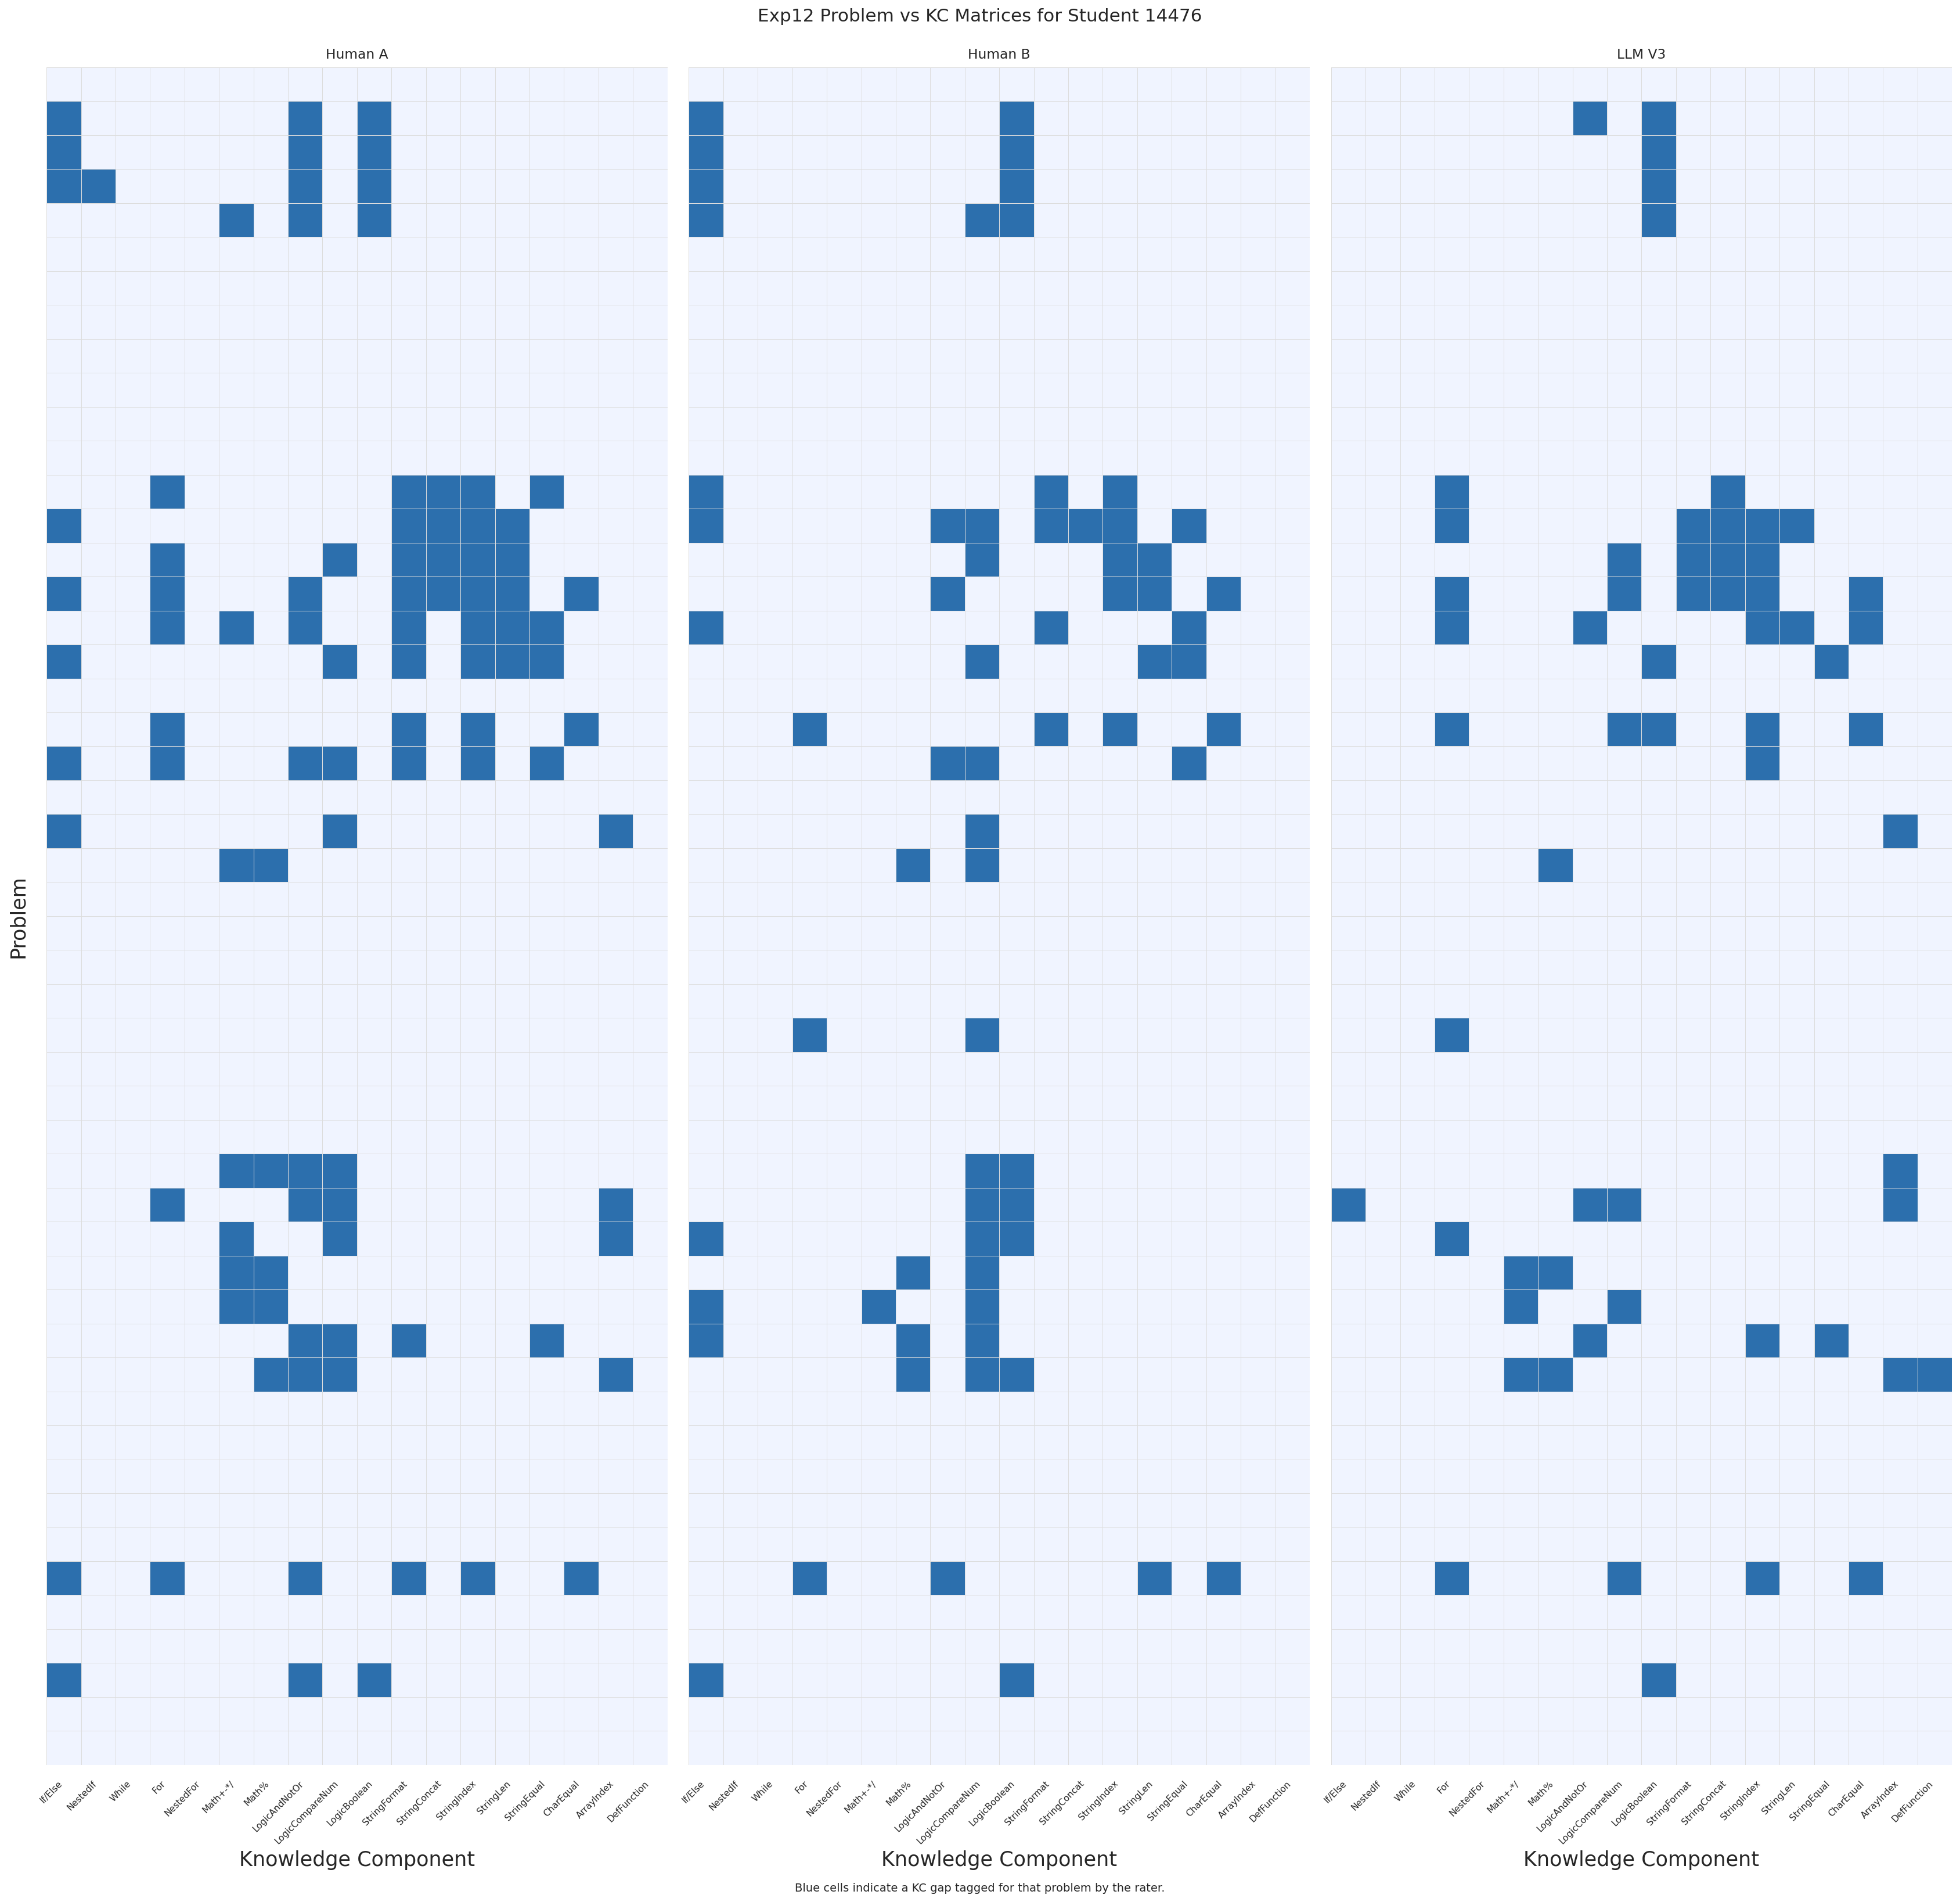

Saved /mnt/d/Projects/kintsugi/results/human_validation/exp12_visualizations/exp12_problem_vs_kc_matrices_student_14476.png


In [21]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.dpi'] = 140

ROOT = Path.cwd()
if not (ROOT / 'results').exists() and (ROOT.parent / 'results').exists():
    ROOT = ROOT.parent

HUMAN_A_FILES = [
    ROOT / 'dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_10155_1774736175604.json',
    ROOT / 'dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_14475_1775593592812.json',
    ROOT / 'dataset/Rater_KC_Tags/kc_annotations_Pranay Ghuge_14476_1775593175294.json',
]
HUMAN_B_FILES = [
    ROOT / 'dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_10155_1774820622134.json',
    ROOT / 'dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_14475_1775593132134.json',
    ROOT / 'dataset/Rater_KC_Tags/kc_annotations_Arundhati Das_14476_1775691915454.json',
]
V3_FILES = [
    ROOT / 'results/human_validation/llm_v3_annotations_10155.json',
    ROOT / 'results/human_validation/llm_v3_annotations_14475.json',
    ROOT / 'results/human_validation/llm_v3_annotations_14476.json',
]
FIG_DIR = ROOT / 'results/human_validation/exp12_visualizations'
FIG_DIR.mkdir(parents=True, exist_ok=True)

KC_COLUMNS = [
    'If/Else', 'NestedIf', 'While', 'For', 'NestedFor',
    'Math+-*/', 'Math%', 'LogicAndNotOr', 'LogicCompareNum', 'LogicBoolean',
    'StringFormat', 'StringConcat', 'StringIndex', 'StringLen',
    'StringEqual', 'CharEqual', 'ArrayIndex', 'DefFunction'
 ]

def load_annotations(filepath: Path):
    with filepath.open('r', encoding='utf-8') as f:
        data = json.load(f)
    rater_name = data.get('rater', filepath.stem)
    student_id = str(data.get('student_id', data.get('studentId', 'unknown')))
    annotations = {}
    for pid, item in data.get('annotations', {}).items():
        if isinstance(item, dict):
            gaps = item.get('gaps', [])
        elif isinstance(item, list):
            gaps = item
        else:
            gaps = []
        comp_pid = f'{student_id}_{pid}'
        annotations[comp_pid] = {kc for kc in gaps if kc in KC_COLUMNS}
    return rater_name, student_id, annotations

def merge_rater_files(filepaths):
    merged = {}
    for fp in filepaths:
        rater_name, student_id, ann = load_annotations(fp)
        merged.setdefault(rater_name, {})
        merged[rater_name].update(ann)
    return merged

anns_by_rater = {
    'Human A': {},
    'Human B': {},
    'LLM V3': {},
}

for fp in HUMAN_A_FILES:
    _, sid, ann = load_annotations(fp)
    anns_by_rater['Human A'].update(ann)

for fp in HUMAN_B_FILES:
    _, sid, ann = load_annotations(fp)
    anns_by_rater['Human B'].update(ann)

for fp in V3_FILES:
    _, sid, ann = load_annotations(fp)
    anns_by_rater['LLM V3'].update(ann)

students = sorted({pid.split('_')[0] for ann in anns_by_rater.values() for pid in ann.keys()}, key=int)

print(f'Students found: {students}')

cmap = ListedColormap(['#f0f4ff', '#2c6fad'])

for student in students:
    student_pids = sorted(
        set(pid for ann in anns_by_rater.values() for pid in ann.keys() if pid.startswith(f'{student}_')),
        key=lambda pid: int(pid.split('_', 1)[1]),
    )
    if not student_pids:
        continue

    problem_labels = [f'P{pid.split("_", 1)[1]}' for pid in student_pids]
    fig, axes = plt.subplots(
        1, 3,
        figsize=(24, max(8, len(student_pids) * 0.45)),
        sharey=True,
        constrained_layout=True,
    )
    if len(student_pids) == 1:
        axes = [axes]

    for ax, (rater_name, ann) in zip(axes, anns_by_rater.items()):
        matrix = np.zeros((len(student_pids), len(KC_COLUMNS)), dtype=int)
        for r, pid in enumerate(student_pids):
            for c, kc in enumerate(KC_COLUMNS):
                matrix[r, c] = 1 if kc in ann.get(pid, set()) else 0

        sns.heatmap(
            matrix,
            ax=ax,
            cmap=cmap,
            vmin=0, vmax=1,
            cbar=False,
            linewidths=0.35,
            linecolor='#dddddd',
            yticklabels=problem_labels,
            xticklabels=KC_COLUMNS,
        )
        ax.set_title(rater_name, fontsize=12, pad=8)
        ax.set_xlabel('Knowledge Component')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
        ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)

    axes[0].set_ylabel('Problem')
    axes[1].set_ylabel('')
    axes[2].set_ylabel('')

    fig.suptitle(f'Exp12 Problem vs KC Matrices for Student {student}', fontsize=16, y=1.02)
    fig.text(0.5, -0.01, 'Blue cells indicate a KC gap tagged for that problem by the rater.', ha='center', fontsize=10)
    matrix_path = FIG_DIR / f'exp12_problem_vs_kc_matrices_student_{student}.png'
    fig.savefig(matrix_path, bbox_inches='tight')
    plt.show()
    print(f'Saved {matrix_path}')